|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 6:</h2>|<h1>The Server<h1>|
|<h2>Section:</h2>|<h1>Observability<h1>|
|<h2>Lecture:</h2>|<h1><b>Six numbers, a Pareto frontier, and why throughput is not the answer<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

rng = np.random.default_rng(0)

# The six numbers

You cannot tune what you cannot see, and you will misdiagnose every
performance problem you have if you are missing any of these:

| | what it is | who cares |
|---|---|---|
| **TTFT** | time to first token | the user watching a cursor |
| **TPOT / ITL** | time per output token | the user watching text appear |
| **throughput** | tokens per second, everyone | your bill |
| **queue wait** | arrival to first step | your capacity planning |
| **KV utilisation** | fraction of the pool in use | how close to the edge you are |
| **preemption rate** | how often you undo work | whether you are past it |

The last two are the ones people leave out, and they are the ones that turn
"the server got slow" into an answer.

In [2]:
from dataclasses import dataclass

BLOCK = 16
PROMPT = 48

@dataclass(eq=False)
class Request:
  index: int
  length: int        # tokens that it holds now: the prompt, then each new token
  target: int        # the length at which it finishes

def blocks_for(num_tokens):
  return -(-num_tokens // BLOCK)                # ceiling division

def preempt_newest(running, waiting, protect):
  """Take the blocks of the newest running request. It starts again later.
  -> the freed blocks."""
  victim = running[-1] if running[-1] is not protect else running[-2]
  freed = blocks_for(victim.length)
  victim.length = PROMPT
  running.remove(victim)
  waiting.insert(0, victim)
  return freed

def simulate(max_num_seqs, arrival_rate, num_requests=4000, pool_blocks=800):
  """A whole server, as a token counter. The clock counts steps.
  -> the timings of each request, and the state of the server."""
  lengths = rng.lognormal(mean=np.log(120), sigma=0.9, size=num_requests).astype(int) + 1
  arrivals = np.cumsum(rng.exponential(1/arrival_rate, size=num_requests))
  free, reserve = pool_blocks, max(1, pool_blocks//20)
  waiting, running = [], []
  ttft = np.full(num_requests, np.nan)
  latency = np.full(num_requests, np.nan)
  next_arrival, clock, preemptions = 0, 0.0, 0
  batch_sizes, kv_fractions = [], []
  while next_arrival < num_requests or waiting or running:
    while next_arrival < num_requests and arrivals[next_arrival] <= clock:
      waiting.append(Request(next_arrival, PROMPT, PROMPT + int(lengths[next_arrival])))
      next_arrival += 1
    while (waiting and len(running) < max_num_seqs
           and free - blocks_for(waiting[0].length) >= reserve):
      request = waiting.pop(0)
      free -= blocks_for(request.length)
      running.append(request)
    if not running:
      if next_arrival >= num_requests:
        break
      clock = arrivals[next_arrival]
      continue
    batch_sizes.append(len(running))
    kv_fractions.append(1 - free/pool_blocks)   # a sample at each step, not only at the end
    clock += 1.0                                 # ONE step. The clock counts steps.
    for request in list(running):
      if request not in running:
        continue
      if request.length % BLOCK == 0:
        while free == 0 and len(running) > 1:
          free += preempt_newest(running, waiting, request)
          preemptions += 1
        if free == 0:
          break
        free -= 1
      if np.isnan(ttft[request.index]):
        ttft[request.index] = clock - arrivals[request.index]
      request.length += 1
      if request.length >= request.target:
        latency[request.index] = clock - arrivals[request.index]
        running.remove(request)
        free += blocks_for(request.length)
  finished = ~np.isnan(latency)
  return dict(ttft=ttft[finished], latency=latency[finished],
              finished=int(finished.sum()), makespan=clock, preemptions=preemptions,
              occupancy=np.mean(batch_sizes)/max_num_seqs,
              kv_used=float(np.mean(kv_fractions)), kv_peak=float(np.max(kv_fractions)))

In [3]:
# arrival_rate is in requests for each STEP. So nothing here is in seconds,
# and nothing depends on the speed of your card. The unit is a step.
result = simulate(max_num_seqs=64, arrival_rate=0.20)
print(f"finished     {result['finished']}")
print(f"TTFT p50     {np.median(result['ttft']):6.1f} steps   "
      f"p99 {np.percentile(result['ttft'],99):6.1f}")
print(f"latency p50  {np.median(result['latency']):6.1f} steps   "
      f"p99 {np.percentile(result['latency'],99):6.1f}")
print(f"throughput   {result['finished']/result['makespan']:6.3f} requests for each step")
print(f"occupancy    {100*result['occupancy']:6.1f}% of slots")
print(f"KV used      {100*result['kv_used']:6.1f}% mean, {100*result['kv_peak']:.1f}% peak")
print(f"preemptions  {result['preemptions']}")

finished     4000
TTFT p50        1.6 steps   p99  135.6
latency p50   132.3 steps   p99  977.0
throughput    0.194 requests for each step
occupancy      54.3% of slots
KV used        66.0% mean, 100.0% peak
preemptions  194


# The curve that decides max_num_seqs

Sweep the concurrency limit and plot throughput against tail latency. There
is no best point on it, only a frontier and a decision about which end you
want to live on.

In [4]:
seq_limits = [4, 8, 16, 32, 64, 128, 256]
results = [simulate(max_num_seqs=limit, arrival_rate=0.45)     # overloaded
           for limit in seq_limits]
throughputs = np.array([result['finished']/result['makespan'] for result in results])
p99_latencies = np.array([np.percentile(result['latency'], 99) for result in results])
p99_ttfts = np.array([np.percentile(result['ttft'], 99) for result in results])
print(f"{'max_num_seqs':>13} {'req/step':>9} {'p99 TTFT':>10} {'p99 lat':>10} "
      f"{'KV peak':>9} {'preempt':>8}")
for limit, result, throughput, ttft, latency in zip(
    seq_limits, results, throughputs, p99_ttfts, p99_latencies):
  print(f'{limit:>13} {throughput:>9.3f} {ttft:>9.0f} {latency:>9.0f} '
        f'{100*result["kv_peak"]:>8.1f}% {result["preemptions"]:>8}')

 max_num_seqs  req/step   p99 TTFT    p99 lat   KV peak  preempt
            4     0.022    170155    170371     37.4%        0
            8     0.044     80836     81024     53.6%        0
           16     0.087     35426     35593     65.5%        0
           32     0.171     13702     13870     97.2%        0
           64     0.266      5105      5407    100.0%      811
          128     0.261      5659      5940    100.0%     1177
          256     0.246      6582      6868    100.0%     1259


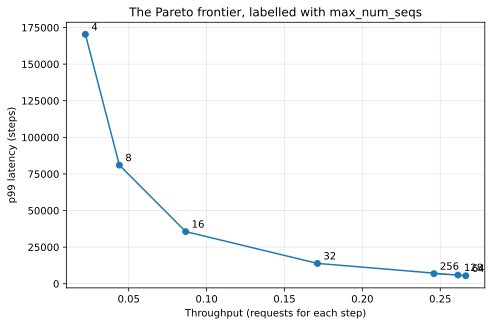

In [5]:
plt.figure(figsize=(7.5,4.8))
plt.plot(throughputs, p99_latencies, 'o-')
for limit, throughput, latency in zip(seq_limits, throughputs, p99_latencies):
  plt.annotate(f'{limit}', (throughput, latency),
               textcoords='offset points', xytext=(6,4))
plt.xlabel('Throughput (requests for each step)')
plt.ylabel('p99 latency (steps)')
plt.title('The Pareto frontier, labelled with max_num_seqs')
plt.grid(alpha=.3)
plt.show()

### Goodput: the only number that is actually the answer

Throughput counts everything you finished. Goodput counts what you finished
**within the latency target you promised**. A server can have excellent
throughput and almost no goodput, and a throughput-only dashboard will look
fine the whole time.

In [6]:
def goodput(result, sla_steps):
  """The rate of requests that finished inside the SLA, for each step."""
  within_sla = (result['latency'] <= sla_steps).mean()
  return within_sla * result['finished'] / result['makespan']

# The SLAs are in steps, because the simulation counts steps. Multiply by
# the step time that you measured to get seconds.
for sla_steps in (200, 600, 3000):
  goodputs = [goodput(result, sla_steps) for result in results]
  best = seq_limits[int(np.argmax(goodputs))]
  print(f'SLA {sla_steps:>5} steps: best max_num_seqs = {best:>4}   '
        f'(goodput {max(goodputs):.3f} of {throughputs.max():.3f} req/step raw)')

SLA   200 steps: best max_num_seqs =   64   (goodput 0.010 of 0.266 req/step raw)
SLA   600 steps: best max_num_seqs =   64   (goodput 0.032 of 0.266 req/step raw)
SLA  3000 steps: best max_num_seqs =   64   (goodput 0.151 of 0.266 req/step raw)


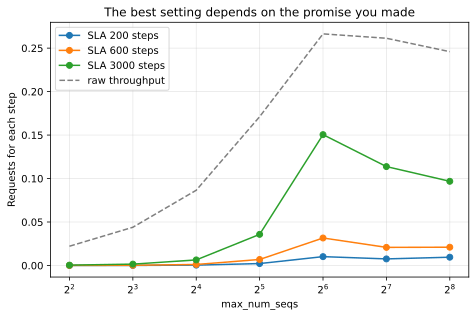

In [7]:
plt.figure(figsize=(7.5,4.6))
for sla_steps in (200, 600, 3000):
  plt.plot(seq_limits, [goodput(result, sla_steps) for result in results], 'o-',
           label=f'SLA {sla_steps} steps')
plt.plot(seq_limits, throughputs, 'k--', alpha=.5, label='raw throughput')
plt.xscale('log', base=2)
plt.xlabel('max_num_seqs')
plt.ylabel('Requests for each step')
plt.title('The best setting depends on the promise you made')
plt.legend()
plt.grid(alpha=.3)
plt.show()

### The shape to notice is the collapse, not the frontier

Throughput climbs to a peak around 64 and then **falls**. Not levels off:
falls. At 256 slots the server does less work than at 64, on the same
hardware, with the same requests.

The reason is in the last two columns and nowhere else. KV peak hits 100%,
preemptions go up by an order of magnitude, and the machine spends its time
regenerating tokens it had already produced. From the outside this looks like
a hardware problem, a network problem, or a bad day.

So the honest version of 'tune max_num_seqs for throughput' is narrower than
it sounds. Past the point where KV memory saturates, more concurrency is not
a trade against latency. It is worse at both.

### And why goodput is the number, not throughput

Throughput counts everything you finished. Goodput counts what you finished
within the promise you made. They disagree whenever the queue is long, which
is exactly when you are looking at the dashboard.

This is why stage 16 comes before the clever stages rather than after.
[Speculative decoding](../../GLOSSARY.md#speculative-decoding) and quantization each trade one of these six numbers for
another, and without all six you cannot tell whether you came out ahead.

    ./vc guide 16